In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import datetime
%matplotlib inline

In [12]:
#load wave data

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

print(df_wave.head())
print(f"\nTotal records: {len(df_wave)}")
print(f"Time range: {df_wave.index[0]} to {df_wave.index[-1]}")

                         Hs_m       Tp_s
2010-01-01 00:00:00  4.356820  11.297707
2010-01-01 03:00:00  4.161001  11.206398
2010-01-01 06:00:00  4.123161  11.046730
2010-01-01 09:00:00  4.093586  11.074074
2010-01-01 12:00:00  4.266944  11.590187

Total records: 32144
Time range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00


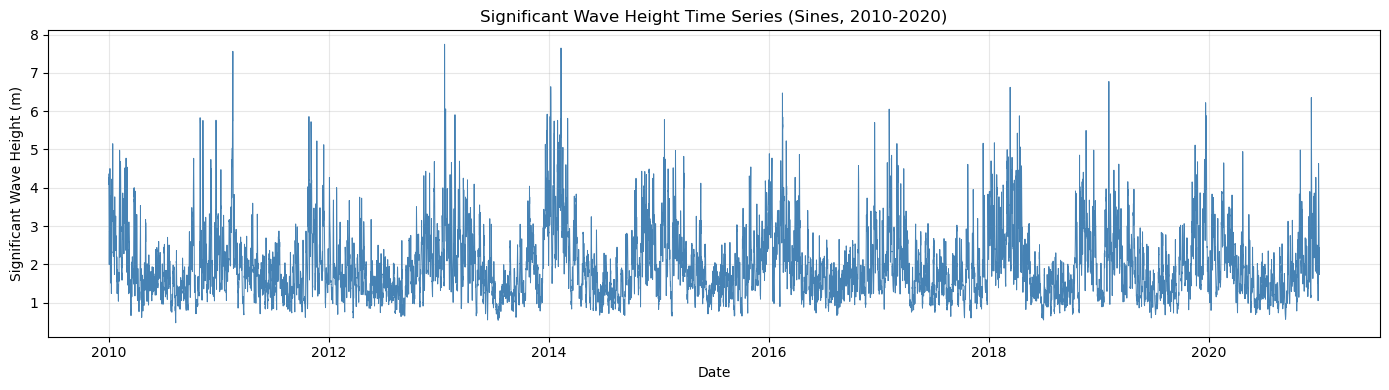

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(df_wave.index, df_wave['Hs_m'], color='steelblue', linewidth=0.7) 
plt.xlabel('Date')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height Time Series (Sines, 2010-2020)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

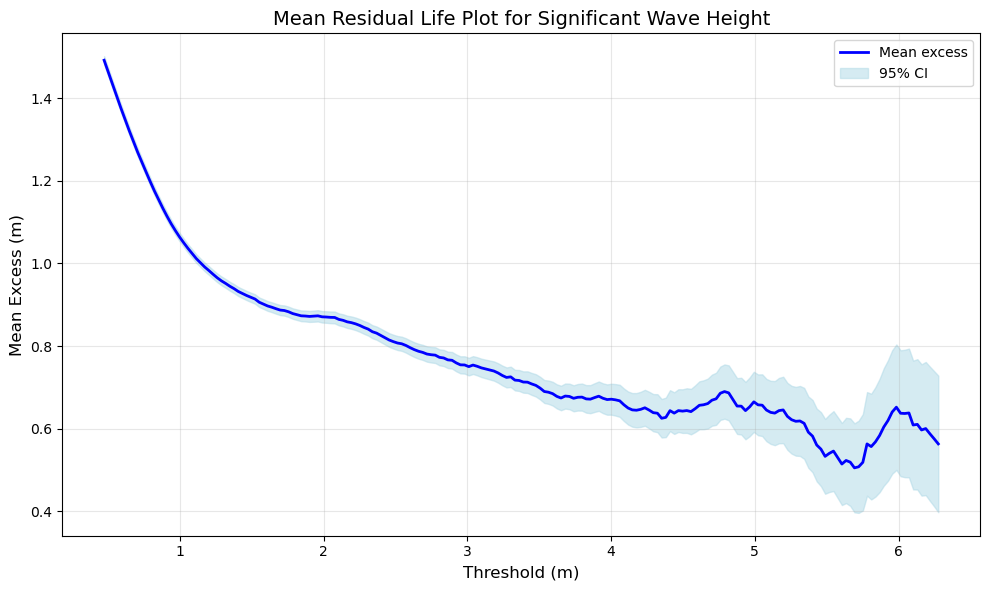

In [41]:
def mrl_plot(data, threshold_range=None):
    #"MRL plot presents in the x-axis different values of th and, in the y-axis, the mean excess for that
    #value of the th. The range of appropriate threshold would be that where the mean excesses
    #follows a linear trend"
    if threshold_range is None:
        threshold_range = np.linspace(data.min(), data.quantile(0.999), 200)
    
    mean_excesses =[]
    ci_upper = []
    ci_lower = []
    for th in threshold_range:
        excesses = data[data > th] - th
        if len(excesses)<5:
            break
        me = excesses.mean()
        se= excesses.std() / np.sqrt(len(excesses))
        
        mean_excesses.append(me)
        ci_upper.append(me + 1.96*se)
        ci_lower.append(me - 1.96*se)
        
    th_plot = threshold_range[:len(mean_excesses)]

    plt.figure(figsize=(10, 6))
    plt.plot(th_plot, mean_excesses, 'b', linewidth=2, label='Mean excess')
    plt.fill_between(th_plot, ci_lower, ci_upper, color='lightblue', alpha=0.5, label='95% CI')
    plt.xlabel('Threshold (m)', fontsize=12)
    plt.ylabel('Mean Excess (m)', fontsize=12)
    plt.title('Mean Residual Life Plot for Significant Wave Height', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_mrl.png', dpi=300, bbox_inches='tight')
    plt.show()
    return th_plot, mean_excesses

th_range, me = mrl_plot(df_wave['Hs_m'])


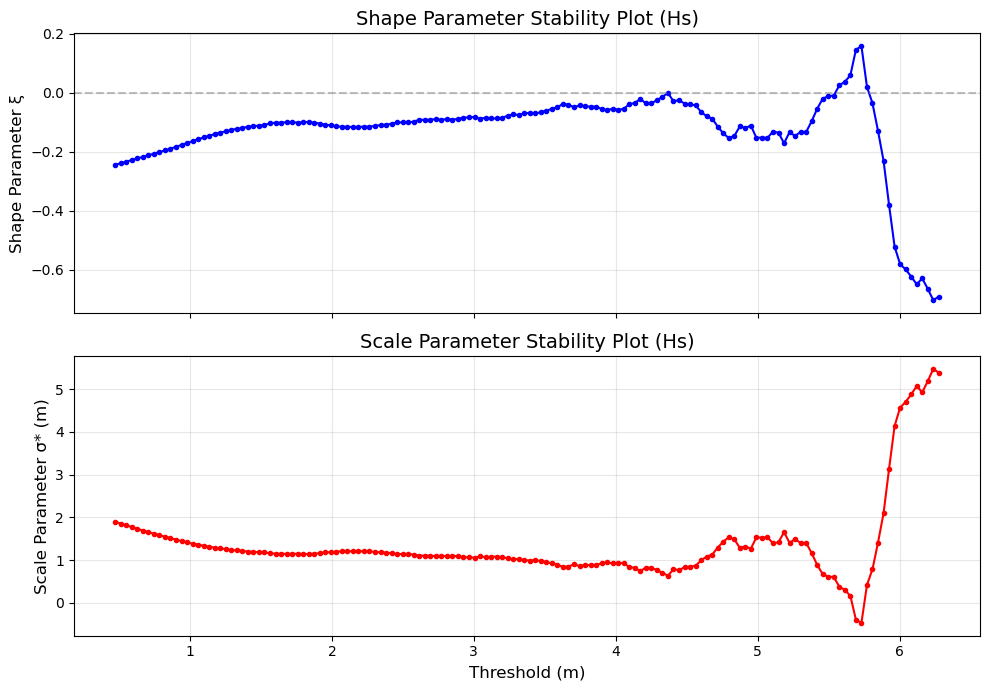

In [42]:
def parameter_stability_plot(data, threshold_range=None):
    
    if threshold_range is None:
        threshold_range = np.linspace(data.min(), data.quantile(0.999), 150)
    
    shapes = []
    scales_star = []
    th_valid = []

    for th in threshold_range:
        excesses = data[data > th] - th
        if len(excesses) < 10:
            break
        try: 
            xi, loc, sigma = stats.genpareto.fit(excesses, floc=0)
            sigma_star = sigma - xi *th
            shapes.append(xi)
            scales_star.append(sigma_star)
            th_valid.append(th)
        except:
            continue

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(th_valid, shapes, 'b-o', markersize=3)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Shape Parameter ξ', fontsize=12)
    ax1.set_title('Shape Parameter Stability Plot (Hs)', fontsize=14)
    ax1.grid(True, alpha=0.3)

    ax2.plot(th_valid, scales_star, 'r-o', markersize=3)
    ax2.set_xlabel('Threshold (m)', fontsize=12)    
    ax2.set_ylabel('Scale Parameter σ* (m)', fontsize=12)
    ax2.set_title('Scale Parameter Stability Plot (Hs)', fontsize=14)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_parameter_stability.png', dpi=300, bbox_inches='tight')
    plt.show()

parameter_stability_plot(df_wave['Hs_m'])

In [25]:
print(f"3m is the {(df_wave['Hs_m'] < 3.0).mean()*100:.1f}th percentile")

3m is the 87.1th percentile


shape parameter stays around -0.10 m between 2.5 and 3.5m
scale parameter stays around 1.1 m betweeen 2.5m and 3.5m
th = 3.0m  
- falls in the stable region of both plots  
- looking at time series, 3m separates storm conditions from normal sea states   
- mean of Hs is 1.96m, so 3m is approximately the 85th percentile  
- gives enough peaks for a reliable GPD fit (around 5 to 8 storms per year)

In [27]:
for th_test in [3.0, 3.5, 4.0, 4.5, 5.0]:
    peaks_test, _ = find_peaks(hs, height=th_test, distance=dl_steps)
    print(f"th = {th_test}m: {len(peaks_test)} peaks, {len(peaks_test)/n_years:.1f} per year")

th = 3.0m: 282 peaks, 28.2 per year
th = 3.5m: 185 peaks, 18.5 per year
th = 4.0m: 124 peaks, 12.4 per year
th = 4.5m: 79 peaks, 7.9 per year
th = 5.0m: 38 peaks, 3.8 per year


Threshold: 4.5 m
Declustering window: 72 hours (24 steps)
Number of peaks identified: 79
Average peaks per year: 7.90


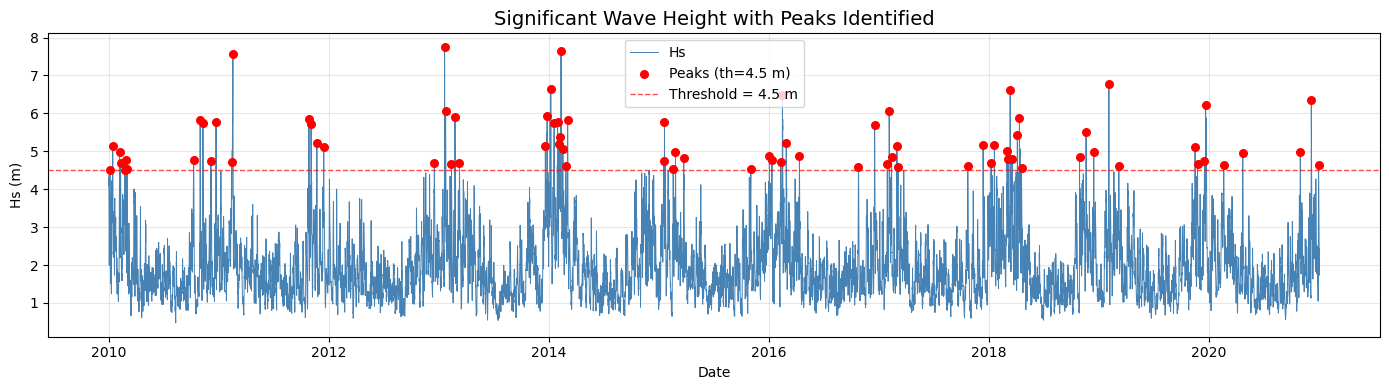

Excess statistics:
Mean excess: 0.773 m
max excess: 3.249 m
min excess: 0.002 m


In [37]:
# POT parameters 
th = 4.5
dl = 72  #h, typical for Atlantic storms https://www.sciencedirect.com/science/article/pii/S2212094724000628
n_years = 10 

dl_steps = int(dl /3)  #we have 3-hourly data 

hs = df_wave['Hs_m'].values
time = df_wave.index

peak_indices, _ = find_peaks(hs, height=th, distance = dl_steps)
peak_values = hs[peak_indices]
peak_times = time[peak_indices]
lambda_hat= len(peak_values) / n_years
print(f"Threshold: {th} m")
print(f"Declustering window: {dl} hours ({dl_steps} steps)")
print(f"Number of peaks identified: {len(peak_values)}")
print(f"Average peaks per year: {len(peak_values)/n_years:.2f}")

plt.figure(figsize=(14, 4))
plt.plot(time, hs, color='steelblue', linewidth=0.7, label='Hs')
plt.scatter(peak_times, peak_values, color='red', s=30, zorder=5, label=f'Peaks (th={th} m)')
plt.axhline(th, color='red', linestyle='--', linewidth=1, alpha=0.7,label=f'Threshold = {th} m')
plt.xlabel('Date')
plt.ylabel('Hs (m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Significant Wave Height with Peaks Identified', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_peaks.png', dpi=300, bbox_inches='tight')
plt.show()

excesses = peak_values - th
print(f"Excess statistics:") 
print(f"Mean excess: {excesses.mean():.3f} m")
print(f"max excess: {excesses.max():.3f} m")   
print(f"min excess: {excesses.min():.3f} m")


GPD parameters:
Shape, ξ: -0.042
Location, μ: 0.000
Scale, σ: 0.806

 ξ < 0 → Bounded Weibull tail (upper bound exists)
Upper bound: 23.635 m


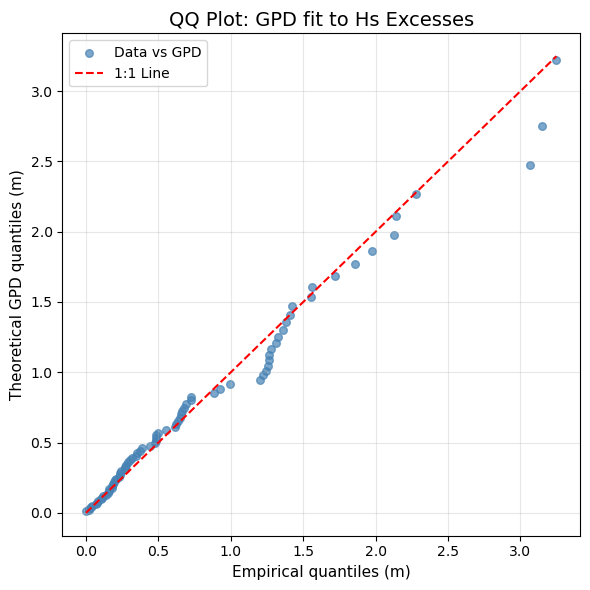

In [38]:
xi, loc, sigma = stats.genpareto.fit(excesses, floc=0)
print(f"\nGPD parameters:")
print(f"Shape, ξ: {xi:.3f}")
print(f"Location, μ: {loc:.3f}")
print(f"Scale, σ: {sigma:.3f}")

if xi <0: 
    print(f"\n ξ < 0 → Bounded Weibull tail (upper bound exists)")
    upper_bound = th - sigma/xi
    print(f"Upper bound: {upper_bound:.3f} m")
elif xi == 0:
    print(f"\n ξ = 0 → Exponential tail")
else:
    print(f"\n ξ > 0 → Heavy Fréchet tail (no upper bound)")

n = len(excesses)
sorted_excesses = np.sort(excesses)
empirical_probs = np.arange (1, n+1) / (n+1)
theoretical_quantiles = stats.genpareto.ppf(empirical_probs, c=xi, loc=loc, scale=sigma)

plt.figure(figsize=(6,6))
plt.scatter(sorted_excesses, theoretical_quantiles, color='steelblue', s=30, alpha=0.7, label = 'Data vs GPD')
max_val = max(sorted_excesses.max(), theoretical_quantiles.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='1:1 Line')
plt.xlabel('Empirical quantiles (m)', fontsize=11)
plt.ylabel('Theoretical GPD quantiles (m)', fontsize=11)
plt.title('QQ Plot: GPD fit to Hs Excesses', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_gpd_qq.png', dpi=300, bbox_inches='tight')
plt.show()


Return levels (Hs):
  Return Period     Hs (m)
----------------------------
           1 yr      6.10 m
          10 yr      7.72 m
          50 yr      8.76 m
         100 yr      9.19 m


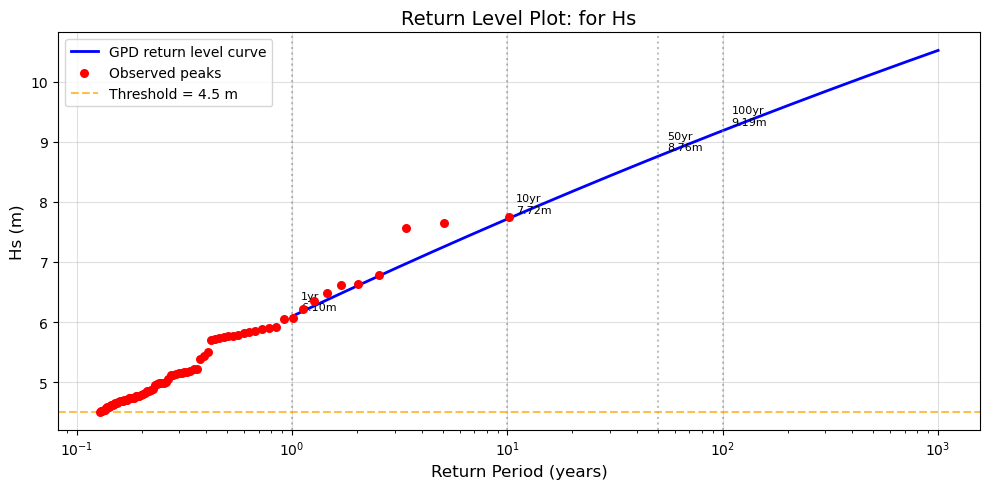

In [40]:
return_periods = [1, 10, 50, 100]
print(f"\nReturn levels (Hs):")
print(f"{'Return Period':>15} {'Hs (m)':>10}")
print("-" * 28)

for TR in return_periods:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    print(f"{TR:>12} yr  {x_TR:>8.2f} m")

TR_range = np.logspace(0, 3, 200)  # 1 to 1000 years
if xi != 0:
    hs_return = th + (sigma / xi) * ((lambda_hat * TR_range)**xi - 1)
else:
    hs_return = th + sigma * np.log(lambda_hat * TR_range)

n_peaks = len(peak_values)
sorted_peaks = np.sort(peak_values)
emp_probs = np.arange(1, n_peaks+1) / (n_peaks + 1)
emp_TR = 1 / (lambda_hat * (1 - emp_probs))

plt.figure(figsize=(10, 5))
plt.semilogx(TR_range, hs_return, 'b-', linewidth=2, label='GPD return level curve')
plt.scatter(emp_TR, sorted_peaks, color='red', s=30, zorder=5, label='Observed peaks')
for TR in [1, 10, 50, 100]:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    plt.axvline(TR, color='gray', linestyle=':', alpha=0.5)
    plt.annotate(f'{TR}yr\n{x_TR:.2f}m', xy=(TR, x_TR),
                 xytext=(TR*1.1, x_TR+0.1), fontsize=8)

plt.axhline(th, color='orange', linestyle='--', alpha=0.7, label=f'Threshold = {th} m')
plt.xlabel('Return Period (years)', fontsize=12)
plt.ylabel('Hs (m)', fontsize=12) 
plt.title('Return Level Plot: for Hs', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA\hs_return_period.png', dpi=300, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Carolina\\Documents\\MSc Civil Engineering\\Marine renewables\\marine renewables\\Marine-renewables\\data aquisition\\data\\EVA\\return_levels_hs_CI.png'

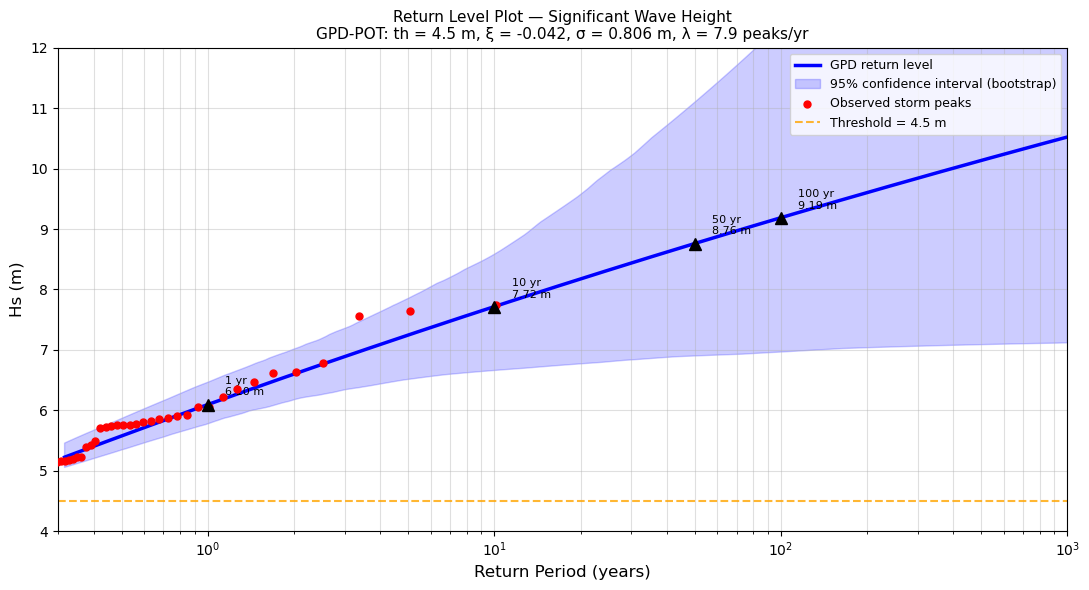

In [43]:
n_bootstrap = 500
TR_range = np.logspace(-0.5, 3, 300)  # 0.3 to 1000 years
hs_boot = np.zeros((n_bootstrap, len(TR_range)))

np.random.seed(42)
for i in range(n_bootstrap):
    boot_excesses = np.random.choice(excesses, size=len(excesses), replace=True)
    try:
        xi_b, _, sigma_b = stats.genpareto.fit(boot_excesses, floc=0)
        if xi_b != 0:
            hs_boot[i] = th + (sigma_b / xi_b) * ((lambda_hat * TR_range)**xi_b - 1)
        else:
            hs_boot[i] = th + sigma_b * np.log(lambda_hat * TR_range)
    except:
        hs_boot[i] = np.nan

# Central estimate
if xi != 0:
    hs_return = th + (sigma / xi) * ((lambda_hat * TR_range)**xi - 1)
else:
    hs_return = th + sigma * np.log(lambda_hat * TR_range)

# 95% confidence bounds
ci_low  = np.nanpercentile(hs_boot, 2.5,  axis=0)
ci_high = np.nanpercentile(hs_boot, 97.5, axis=0)

# Empirical return periods
sorted_peaks = np.sort(peak_values)
emp_probs    = np.arange(1, len(peak_values)+1) / (len(peak_values) + 1)
emp_TR       = 1 / (lambda_hat * (1 - emp_probs))

# Plot
plt.figure(figsize=(11, 6))
plt.semilogx(TR_range, hs_return, 'b-', linewidth=2.5, label='GPD return level')
plt.fill_between(TR_range, ci_low, ci_high, alpha=0.2, color='blue', 
                 label='95% confidence interval (bootstrap)')
plt.scatter(emp_TR, sorted_peaks, color='red', s=25, zorder=5, 
            label='Observed storm peaks')
plt.axhline(th, color='orange', linestyle='--', alpha=0.8, 
            label=f'Threshold = {th} m')

# Mark the design return periods
return_periods = [1, 10, 50, 100]
for TR in return_periods:
    if xi != 0:
        x_TR = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR = th + sigma * np.log(lambda_hat * TR)
    plt.plot(TR, x_TR, 'k^', markersize=8, zorder=6)
    plt.annotate(f'{TR} yr\n{x_TR:.2f} m', 
                 xy=(TR, x_TR), xytext=(TR*1.15, x_TR + 0.15), fontsize=8)

plt.xlim([0.3, 1000])
plt.ylim([4.0, 12])
plt.xlabel('Return Period (years)', fontsize=12)
plt.ylabel('Hs (m)', fontsize=12)
plt.title(f'Return Level Plot — Significant Wave Height\n'
          f'GPD-POT: th = {th} m, ξ = {xi:.3f}, σ = {sigma:.3f} m, '
          f'λ = {lambda_hat:.1f} peaks/yr', fontsize=11)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.4, which='both')
plt.tight_layout()
plt.savefig(data_dir + r'\EVA\return_levels_hs_CI.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final table
print(f"\n{'Return Period':>15} {'Hs (m)':>10} {'95% CI lower':>15} {'95% CI upper':>15}")
print("-" * 58)
for TR in return_periods:
    if xi != 0:
        x_TR   = th + (sigma / xi) * ((lambda_hat * TR)**xi - 1)
    else:
        x_TR   = th + sigma * np.log(lambda_hat * TR)
    idx    = np.argmin(np.abs(TR_range - TR))
    x_low  = ci_low[idx]
    x_high = ci_high[idx]
    print(f"{TR:>12} yr  {x_TR:>8.2f} m  {x_low:>12.2f} m  {x_high:>12.2f} m")